# Phase 5.2 — Minimal Anomaly Detector (SOC-First)

This notebook introduces a minimal anomaly detector that produces an anomaly score **without heavy ML**.

Implemented detector:
✅ Robust Z-score using **Median Absolute Deviation (MAD)**

Why:
- interpretable anomaly score
- robust to outliers/heavy tails
- SOC-friendly and easy to justify

We evaluate using SOC metrics (not ML metrics):
- alert volume at different thresholds
- BENIGN alert rate (false positives)
- ATTACK alert rate (sanity check hit estimate)
- alert drift across `source_file`

⚠️ We do NOT focus on accuracy/F1/ROC.


## 1) Setup & Output Directories

Notebook execution path may vary (`/notebooks` vs `/phase-5`).

To keep artifacts consistent:
✅ we force outputs into Phase 5 folder:

- `phase-5/outputs/tables/`
- `phase-5/outputs/figures/`


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 140)

# Force outputs into Phase 5 folder (absolute)
PHASE5_DIR = r"D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5"

OUTPUT_DIR = os.path.join(PHASE5_DIR, "outputs")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
TAB_DIR = os.path.join(OUTPUT_DIR, "tables")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

print("✅ Saving outputs to:")
print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)


✅ Saving outputs to:
FIG_DIR: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5\outputs\figures
TAB_DIR: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5\outputs\tables


## 2) Data Loading (Split CICIDS Files)

We load all 8 CICIDS day files and attach `source_file`.

SOC value:
- drift-aware evaluation
- alert volume by day/file
- future gating + baselining alignment


In [2]:
DATA_DIR = r"D:\MachineLearningCVE"

FILES = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]

paths = [os.path.join(DATA_DIR, f) for f in FILES]

dfs = []
for p in paths:
    df_part = pd.read_csv(p, low_memory=False)
    df_part.columns = [c.strip() for c in df_part.columns]
    df_part["source_file"] = os.path.basename(p)
    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=True)
print("Combined shape:", df.shape)
df.head()


Combined shape: (2830743, 80)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
0,49188,4,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,3000000.0,5.000000e+05,4.0,0.0,4,4,4,4.0,0.0,4,4,0,0.0,0.0,0,0,0,0,0,0,40,0,5.000000e+05,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
1,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
2,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
3,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
4,49486,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4000000.0,6.666667e+05,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,6.666667e+05,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,245,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv


## 3) Minimal Preprocessing (Detector Stability)

We apply minimal transformations only:
- strip column names
- replace infinities → NaN
- validate label column and clean values

We avoid over-cleaning because benign bursts must remain visible.


In [3]:
# normalize
df.columns = [c.strip() for c in df.columns]

# replace infinities with NaN
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)

# locate label column
label_candidates = ["Label", "label", "Class", "class", "Attack", "attack"]
label_col = next((c for c in label_candidates if c in df.columns), None)

assert label_col is not None, "Label column not found — check dataset schema."
df[label_col] = df[label_col].astype(str).str.strip()

df[label_col].value_counts().head(20)


Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

## 4) BENIGN Baseline + ATTACK Sanity Slice

BENIGN subset:
- used to compute baseline parameters (median, MAD)

ATTACK subset:
- used only for sanity check hit-rate estimate
- not used for "training"

SOC framing:
This detector is triage-support scoring, not classification.


In [4]:
benign_values = ["BENIGN", "Benign", "benign", "Normal", "NORMAL"]
df_benign = df[df[label_col].isin(benign_values)].copy()
df_attack = df[~df[label_col].isin(benign_values)].copy()

print("BENIGN:", df_benign.shape)
print("ATTACK:", df_attack.shape)

df_attack[label_col].value_counts().head(20)


BENIGN: (2273097, 80)
ATTACK: (557646, 80)


Label
DoS Hulk                      231073
PortScan                      158930
DDoS                          128027
DoS GoldenEye                  10293
FTP-Patator                     7938
SSH-Patator                     5897
DoS slowloris                   5796
DoS Slowhttptest                5499
Bot                             1966
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Infiltration                      36
Web Attack � Sql Injection        21
Heartbleed                        11
Name: count, dtype: int64

## 5) Feature Set (Stable SOC telemetry)

We use a minimal, interpretable feature set aligned with Phase 5.1 baselines:

- duration
- packet volumes
- rate telemetry

Keeping features small prevents noisy detectors and keeps investigation explainable.


In [5]:
features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
]

missing = [f for f in features if f not in df.columns]
missing


[]

## 6) Baseline Parameters (Median + MAD)

For each feature:
- median defines "normal center"
- MAD defines robust deviation scale

MAD is preferred because CICIDS has heavy tails and benign bursts.


In [6]:
def mad(x: pd.Series):
    x = pd.to_numeric(x, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    med = x.median()
    return (x - med).abs().median()

baseline_params = []
for f in features:
    x = pd.to_numeric(df_benign[f], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    med = x.median()
    m = mad(df_benign[f])
    baseline_params.append({
        "feature": f,
        "median": med,
        "mad": m
    })

params_df = pd.DataFrame(baseline_params)
params_df


,feature,median,mad
0,Flow Duration,30996.000000,30947.000000
1,Total Fwd Packets,2.000000,0.000000
2,Total Backward Packets,2.000000,1.000000
3,Flow Bytes/s,5149.772552,5149.772552
4,Flow Packets/s,122.526496,122.137689


In [7]:
params_path = os.path.join(TAB_DIR, "5.2_baseline_params_median_mad.csv")
params_df.to_csv(params_path, index=False)
print("Saved:", params_path)


Saved: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5\outputs\tables\5.2_baseline_params_median_mad.csv


## 7) Robust Z-Score Computation

Per feature:
`robust_z = |x - median| / MAD`

Interpretation:
- low score → within normal baseline
- high score → anomaly candidate


In [8]:
def robust_z(series: pd.Series, median: float, mad_val: float, eps: float = 1e-9):
    x = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
    return (x - median).abs() / (mad_val + eps)

# Build score columns for benign + full dataset
for row in baseline_params:
    f = row["feature"]
    df[f"rz_{f}"] = robust_z(df[f], row["median"], row["mad"])


## 8) Composite Anomaly Score

We aggregate feature-level deviations into one score.

SOC-friendly approach:
✅ take the **maximum deviation**

Reason:
- highlights strongest abnormal behavior
- easy to explain during investigation
- prevents anomaly dilution from averaging


In [20]:
rz_cols = [c for c in df.columns if c.startswith("rz_")]

df["anomaly_score"] = df[rz_cols].max(axis=1, skipna=True)
df["anomaly_score"].describe()


count    2.830743e+06
mean     7.856584e+09
std      7.496678e+11
min      2.642944e-02
25%      3.314155e+02
50%      1.000000e+09
75%      3.000000e+09
max      2.197570e+14
Name: anomaly_score, dtype: float64

## 8.1) BENIGN/ATTACK subsets refresh (Notebook correctness)

Important engineering detail:

We computed `anomaly_score` after creating `df_benign` and `df_attack`.
To prevent stale copies (missing anomaly_score), we refresh subsets now.


In [21]:
df_benign = df[df[label_col].isin(benign_values)].copy()
df_attack = df[~df[label_col].isin(benign_values)].copy()

print("BENIGN w/ score:", df_benign.shape)
print("ATTACK w/ score:", df_attack.shape)


BENIGN w/ score: (2273097, 86)
ATTACK w/ score: (557646, 86)


## 9) Score Distribution (BENIGN vs ATTACK)

We compare score distributions:

Observe:
- BENIGN heavy tails → expected false positives
- overlap between BENIGN and ATTACK → context dependency
- separation tendency → only sanity check

This supports our thesis:
Detection is tradeoff-driven, not clean separability.


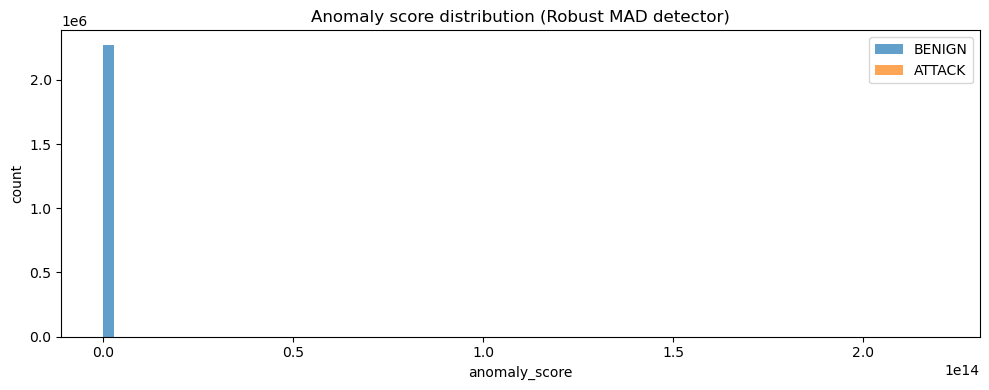

Saved: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5\outputs\figures\5.2_score_distribution.png


In [22]:
plt.figure(figsize=(10,4))

b = df_benign["anomaly_score"].dropna()
a = df_attack["anomaly_score"].dropna()

plt.hist(b, bins=80, alpha=0.7, label="BENIGN")
plt.hist(a, bins=80, alpha=0.7, label="ATTACK")

plt.title("Anomaly score distribution (Robust MAD detector)")
plt.xlabel("anomaly_score")
plt.ylabel("count")
plt.legend()
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "5.2_score_distribution.png")
plt.savefig(fig_path, dpi=240)
plt.show()

print("Saved:", fig_path)


## 10) Threshold Selection (Quantile-based SOC gating)

We choose thresholds using BENIGN quantiles:

- p95
- p99
- p99.5
- p99.9

SOC meaning:
threshold = operational control knob
(higher threshold → fewer alerts → less fatigue)


In [13]:
thresholds = {
    "p95": df_benign["anomaly_score"].quantile(0.95),
    "p99": df_benign["anomaly_score"].quantile(0.99),
    "p995": df_benign["anomaly_score"].quantile(0.995),
    "p999": df_benign["anomaly_score"].quantile(0.999),
}

thresholds


{'p95': 19000000000.0,
 'p99': 53000000000.0,
 'p995': 96000000000.0,
 'p999': 322000000000.0}

In [14]:
thr_df = pd.DataFrame([{"threshold_name": k, "value": v} for k,v in thresholds.items()])
thr_path = os.path.join(TAB_DIR, "5.2_detector_thresholds.csv")
thr_df.to_csv(thr_path, index=False)
print("Saved:", thr_path)

thr_df


Saved: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5\outputs\tables\5.2_detector_thresholds.csv


,threshold_name,value
0,p95,1.900000e+10
1,p99,5.300000e+10
2,p995,9.600000e+10
3,p999,3.220000e+11


## 11) SOC Evaluation (Alert volume + false positives + sanity hit estimate)

We evaluate thresholds using SOC metrics:

- overall alert volume
- BENIGN alert rate (expected false positives)
- ATTACK alert rate (sanity check hit estimate)

This is more realistic than ML accuracy metrics.


In [15]:
def alert_summary(data, thr_value):
    flagged = data["anomaly_score"] >= thr_value
    return {
        "alerts": int(flagged.sum()),
        "alert_rate": float(flagged.mean())
    }

rows = []
for name, val in thresholds.items():
    # Overall
    overall = alert_summary(df, val)
    
    # BENIGN false positive estimate
    benign = alert_summary(df_benign, val)
    
    # ATTACK hit estimate
    attack = alert_summary(df_attack, val)
    
    rows.append({
        "threshold": name,
        "value": val,
        "overall_alerts": overall["alerts"],
        "overall_rate": overall["alert_rate"],
        "benign_alerts": benign["alerts"],
        "benign_rate": benign["alert_rate"],
        "attack_alerts": attack["alerts"],
        "attack_rate": attack["alert_rate"],
    })

summary_df = pd.DataFrame(rows).sort_values("value")
summary_df


,threshold,value,overall_alerts,overall_rate,benign_alerts,benign_rate,attack_alerts,attack_rate
0,p95,1.900000e+10,122454,0.043259,119824,0.052714,2630,0.004716
1,p99,5.300000e+10,23232,0.008207,23121,0.010172,111,0.000199
2,p995,9.600000e+10,11505,0.004064,11395,0.005013,110,0.000197
3,p999,3.220000e+11,2307,0.000815,2285,0.001005,22,0.000039


In [16]:
sum_path = os.path.join(TAB_DIR, "5.2_alert_volume_summary.csv")
summary_df.to_csv(sum_path, index=False)
print("Saved:", sum_path)


Saved: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5\outputs\tables\5.2_alert_volume_summary.csv


## 11.1) Alert volume by source file (Drift-aware SOC evaluation)

SOC operations require day-wise alert analysis.

We compute alerts per `source_file` for each threshold to identify:
- alert storms
- day-specific baseline shifts
- scenarios that distort normal behavior


In [17]:
per_file_rows = []
for name, val in thresholds.items():
    flagged = df["anomaly_score"] >= val
    tmp = df.loc[flagged].groupby("source_file").size().reset_index(name="alerts")
    tmp["threshold"] = name
    per_file_rows.append(tmp)

per_file_df = pd.concat(per_file_rows, ignore_index=True).sort_values(["threshold", "alerts"], ascending=[True, False])
per_file_df.head(20)


,source_file,alerts,threshold
6,Tuesday-WorkingHours.pcap_ISCX.csv,28991,p95
3,Monday-WorkingHours.pcap_ISCX.csv,25250,p95
7,Wednesday-workingHours.pcap_ISCX.csv,23577,p95
4,Thursday-WorkingHours-Afternoon-Infilteration....,13594,p95
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,10239,p95
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,9843,p95
1,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,7338,p95
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,3622,p95
11,Monday-WorkingHours.pcap_ISCX.csv,4894,p99
14,Tuesday-WorkingHours.pcap_ISCX.csv,4774,p99


In [18]:
per_file_path = os.path.join(TAB_DIR, "5.2_alerts_per_file.csv")
per_file_df.to_csv(per_file_path, index=False)
print("Saved:", per_file_path)


Saved: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5\outputs\tables\5.2_alerts_per_file.csv


## 12) Preview Top Alerts (Investigation Packet teaser)

We inspect the strictest threshold output to see:
- which traffic gets flagged
- whether alerts are BENIGN bursts vs attacks
- what features look extreme

This prepares Phase 5.4 investigation packets.


In [19]:
# Use strictest threshold for preview
thr = thresholds["p999"]

alerts = df[df["anomaly_score"] >= thr].copy()
print("Alerts at p999:", alerts.shape)

cols_to_show = ["source_file", label_col, "anomaly_score"] + features
alerts[cols_to_show].head(20)


Alerts at p999: (2307, 86)


,source_file,Label,anomaly_score,Flow Duration,Total Fwd Packets,Total Backward Packets,Flow Bytes/s,Flow Packets/s
185,Monday-WorkingHours.pcap_ISCX.csv,BENIGN,4.120000e+11,1158808,414,512,933809.569834,799.097003
354,Monday-WorkingHours.pcap_ISCX.csv,BENIGN,1.184000e+12,31021236,1186,1396,93505.107276,83.233305
369,Monday-WorkingHours.pcap_ISCX.csv,BENIGN,1.009000e+12,62101008,1011,1807,51134.741645,45.377685
423,Monday-WorkingHours.pcap_ISCX.csv,BENIGN,1.165000e+12,62645702,1167,1737,50861.430206,46.355934
528,Monday-WorkingHours.pcap_ISCX.csv,BENIGN,7.320000e+11,79851783,734,958,22645.342810,21.189258
606,Monday-WorkingHours.pcap_ISCX.csv,BENIGN,4.110000e+11,1898523,413,495,570800.564439,478.266526
720,Monday-WorkingHours.pcap_ISCX.csv,BENIGN,3.340000e+11,113319954,336,0,272.467460,2.965056
1551,Monday-WorkingHours.pcap_ISCX.csv,BENIGN,1.264000e+12,119970563,1266,1828,26777.435395,25.789660
1668,Monday-WorkingHours.pcap_ISCX.csv,BENIGN,3.840000e+11,117094616,386,476,8397.286174,7.361568
1675,Monday-WorkingHours.pcap_ISCX.csv,BENIGN,4.130000e+11,118095120,415,520,9006.849733,7.917347


## Takeaways (Phase 5.2)

- MAD-based anomaly scoring is interpretable and robust without heavy ML.
- Quantile thresholds directly control SOC alert volume.
- BENIGN bursts still trigger alerts → confirms context dependency.
- Detector output is a triage-support signal, not ground truth.

✅ Next: Phase 5.3 will implement alert gating + dedup + rate limiting to prevent alert storms.


### Next Artifact

Phase 5.3 will formalize alert controls in:
- `phase-5/alert_policy.md`

Including:
- dedup rules
- suppression windows
- rate limiting per entity
- severity scoring (signal + context weighting)
